In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import pickle

sys.path.insert(0, "../utils")

from modules import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

In [2]:
df_extnord = pd.read_csv(f'../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)
df_nord = pd.read_csv(f'../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

dataframe = pd.concat([df_extnord, df_nord], ignore_index=True)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [4]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [6]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [7]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

In [8]:
risk_classes = list(range(0,10))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [9]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [10]:
dataframe['case_bin'] = bins

In [11]:
# dataset = pd.concat([data_0, data_rest])

dataset = dataframe.copy()

In [12]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [13]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256  512 1024 8192]


In [14]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

[Text(0, 0, '0'),
 Text(1, 0, '[1-8]'),
 Text(2, 0, '(8-16]'),
 Text(3, 0, '(16-32]'),
 Text(4, 0, '(32-64]'),
 Text(5, 0, '(64-128]'),
 Text(6, 0, '(128-256]'),
 Text(7, 0, '(256-512]'),
 Text(8, 0, '(512-1024]'),
 Text(9, 0, '1024+')]

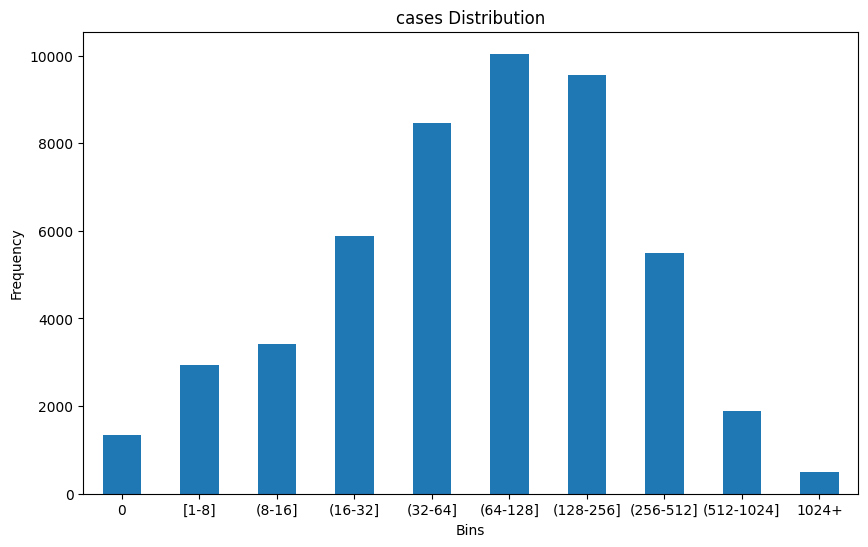

In [15]:
target_col = 'cases'

ax = dataset['case_bin'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title=f'{target_col} Distribution',
    xlabel='Bins',
    ylabel='Frequency'
)

# Set custom x-axis tick labels
ax.set_xticklabels(['0', '[1-8]', '(8-16]', '(16-32]','(32-64]','(64-128]','(128-256]','(256-512]','(512-1024]','1024+'], rotation=0) 
        

In [16]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7,1
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31,3
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49479,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-06,0.000,-1.0,0.513966,0.190414,-0.397487,-0.190414,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,66,5
49480,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-06,0.000,-1.0,0.402476,0.101305,-0.347630,-0.101305,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,140,6
49481,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-06,0.000,-1.0,0.450903,0.092213,-0.381622,-0.092213,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,708,8
49482,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-06,0.000,-1.0,0.454325,0.093292,-0.384450,-0.093292,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,408,7


In [17]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [18]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [19]:
with open("rfecv_model.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

In [20]:
model_params = {
    'objective': 'reg:squarederror',
    'max_depth': 7,
    'learning_rate': 0.3,
    'n_estimators': 150, 
    'min_child_weight': 2,
    'gamma': 0.2,
}

In [21]:
fold_counter = 0
n_models = 10 

y_true_list = []
y_pred_list = []
y_index_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    ## --- Ensemble Model Training ---
    y_pred_ensemble_list = []

    for model in range(n_models):
        print(f"\tEnsemble Model {model+1}/{n_models}", end='\r')
        ensemble_params = model_params.copy()
        ensemble_params['subsample'] = 0.8
        ensemble_params['colsample_bytree'] = 0.8
        ensemble_params['seed'] = model * 100 + fold_counter

        model = xgb.XGBRegressor(**ensemble_params)   
        fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

        y_pred = fitted_model.predict(X_test_rfe)

        y_pred_ensemble_list.append(y_pred)

    y_true_list.append(y_test)
    y_pred_list.append(y_pred_ensemble_list)
    y_index_list.append(test_idx)

    fold_counter += 1
    print('\n', end='\r')

Fold: 1/10
	Ensemble Model 1/10
	Ensemble Model 2/10
	Ensemble Model 3/10
	Ensemble Model 4/10
	Ensemble Model 5/10
	Ensemble Model 6/10
	Ensemble Model 7/10
	Ensemble Model 8/10
	Ensemble Model 9/10
	Ensemble Model 10/10

Fold: 2/10
	Ensemble Model 1/10
	Ensemble Model 2/10
	Ensemble Model 3/10
	Ensemble Model 4/10
	Ensemble Model 5/10
	Ensemble Model 6/10
	Ensemble Model 7/10
	Ensemble Model 8/10
	Ensemble Model 9/10
	Ensemble Model 10/10

Fold: 3/10
	Ensemble Model 1/10
	Ensemble Model 2/10
	Ensemble Model 3/10
	Ensemble Model 4/10
	Ensemble Model 5/10
	Ensemble Model 6/10
	Ensemble Model 7/10
	Ensemble Model 8/10
	Ensemble Model 9/10
	Ensemble Model 10/10

Fold: 4/10
	Ensemble Model 1/10
	Ensemble Model 2/10
	Ensemble Model 3/10
	Ensemble Model 4/10
	Ensemble Model 5/10
	Ensemble Model 6/10
	Ensemble Model 7/10
	Ensemble Model 8/10
	Ensemble Model 9/10
	Ensemble Model 10/10

Fold: 5/10
	Ensemble Model 1/10
	Ensemble Model 2/10
	Ensemble Model 3/10
	Ensemble Model 4/10
	Ensemble Mod

In [22]:
y_true = np.concatenate(y_true_list, axis=0)
y_preds = [np.column_stack(pred) for pred in y_pred_list]
y_pred = np.vstack(y_preds)
# y_pred = np.clip(np.round(y_pred), 0, 9).astype(int)
y_pred = np.clip(y_pred, 0, 9)
y_index = np.concatenate(y_index_list, axis=0)

In [23]:
ens_columns = [f"ens_{i+1}" for i in range(y_pred.shape[1])]

df_ensembles = pd.DataFrame(
    data=y_pred,
    index=y_index,
    columns=ens_columns
)

df_ensembles['y_true'] = y_true
df_ensembles.sort_index(inplace=True)

In [24]:
# Mean prediction (ensemble average)
df_ensembles['y_pred_mean'] = df_ensembles[ens_columns].mean(axis=1)

# Uncertainty (std dev of ensemble predictions)
df_ensembles['y_uncertainty'] = df_ensembles[ens_columns].std(axis=1)

In [25]:
from scipy.stats import norm

z = norm.ppf(0.975)  # ~1.96

df_ensembles['pred_lower'] = df_ensembles['y_pred_mean'] - z * df_ensembles['y_uncertainty']
df_ensembles['pred_upper'] = df_ensembles['y_pred_mean'] + z * df_ensembles['y_uncertainty']

In [26]:
df_ensembles

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,5.171463,4.509984,5.041198,4.710011,4.131264,5.410035,5.083802,4.019822,4.181558,5.112486,5,4.737162,0.498617,3.759890,5.714434
1,2.747197,1.886762,2.581563,2.167473,2.836944,2.839371,2.264379,3.063832,3.715534,2.522859,1,2.662591,0.513183,1.656772,3.668411
2,5.416278,5.003777,4.425461,4.581603,3.974721,5.711162,4.820978,5.526062,5.018422,4.943173,5,4.942164,0.528552,3.906220,5.978107
3,2.732835,2.817652,2.813197,2.771203,3.033712,3.431304,2.933282,2.970159,3.036416,2.359930,3,2.889969,0.273723,2.353481,3.426457
4,3.991455,2.402312,3.927183,3.904290,3.899118,3.616397,3.272414,2.534521,3.184473,4.292222,5,3.502439,0.639121,2.249784,4.755094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49479,4.639615,4.690666,5.260702,5.002234,4.191898,4.571400,4.711978,4.368544,5.184304,4.763625,5,4.738496,0.336313,4.079336,5.397657
49480,5.618721,5.901342,6.053020,5.944937,5.428300,5.432789,5.875618,5.791711,5.790108,6.169920,6,5.800647,0.245828,5.318832,6.282461
49481,7.206559,7.269614,6.566676,6.783465,6.838993,7.672452,7.313258,6.721585,6.692271,7.195428,8,7.026031,0.354321,6.331574,7.720487
49482,6.541388,6.364712,6.411507,7.002773,5.785696,6.029670,6.853149,6.981826,6.642640,6.578178,7,6.519154,0.393239,5.748420,7.289887


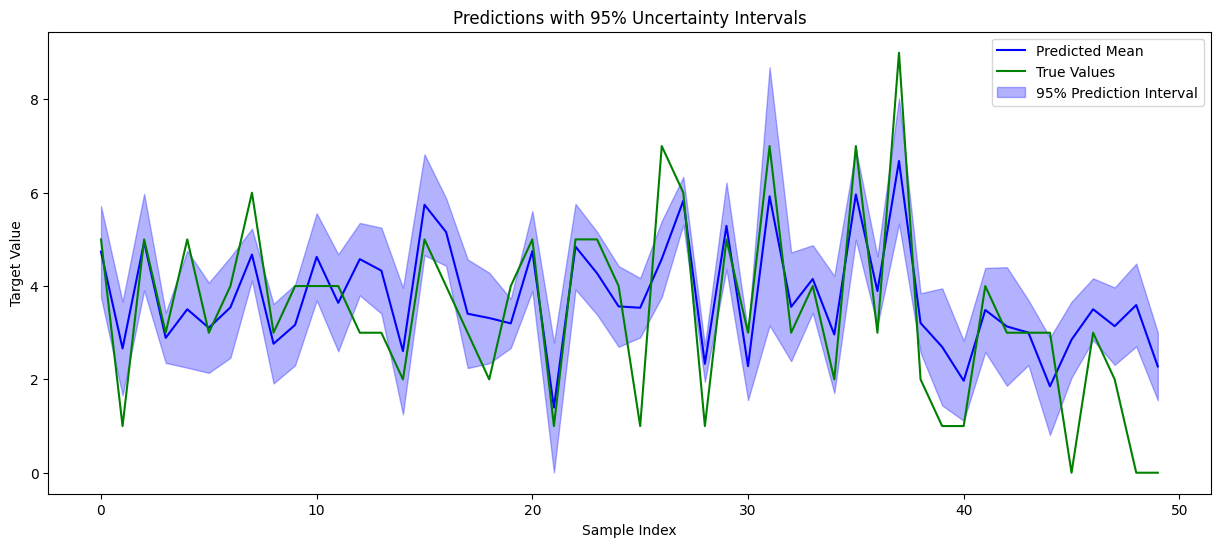

In [27]:
import matplotlib.pyplot as plt

# Select a subset (e.g., first 100 samples) to keep plot clear
subset = df_ensembles.iloc[:50]

plt.figure(figsize=(15,6))

# Plot mean prediction
plt.plot(subset.index, subset["y_pred_mean"], label="Predicted Mean", color="blue")

# Plot ground truth
plt.plot(subset.index, subset["y_true"], label="True Values", color="green")

# Fill between prediction intervals
plt.fill_between(
    subset.index,
    subset["pred_lower"],
    subset["pred_upper"],
    color="blue",
    alpha=0.3,
    label="95% Prediction Interval"
)

plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("Predictions with 95% Uncertainty Intervals")
plt.legend()
plt.show()

In [28]:
df_ensembles_sorted = df_ensembles.sort_values(by='y_pred_mean').reset_index(drop=True)

In [29]:
df_ensembles_sorted.head()

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


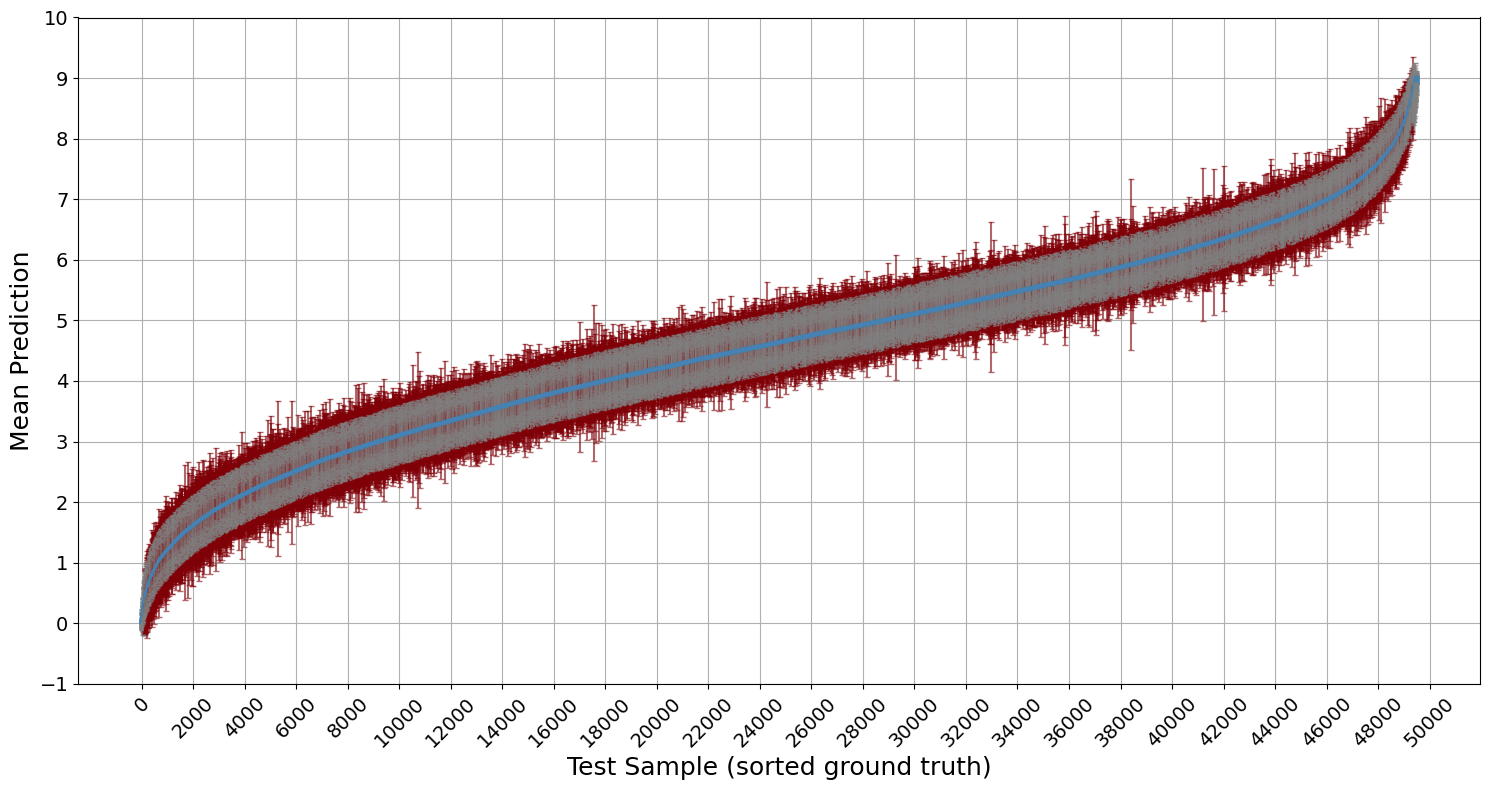

In [30]:
label_size = 18 
tick_size = 14
x_ticks_max = df_ensembles_sorted.shape[0]

plt.figure(figsize=(15, 8))

# Loop through each sample
for i in range(len(df_ensembles_sorted)):
    mean = df_ensembles_sorted['y_pred_mean'].iloc[i]
    std = df_ensembles_sorted['y_uncertainty'].iloc[i]
    
    err_color = '#7f0007' if std > 0.5 else 'gray'

    # Plot error bar only (no marker)
    plt.errorbar(
        x=i,
        y=mean,
        yerr=std,
        fmt='none',          # No marker
        ecolor=err_color,
        alpha=0.4 if err_color == 'grey' else 0.6,           # Alpha for error bars
        capsize=2
    )

    # Plot marker separately
    plt.plot(
        i,
        mean,
        'o',
        markersize=3,
        color='steelblue',       # Marker color
        alpha=1           # Alpha for marker
    )

plt.xlabel("Test Sample (sorted ground truth)", size=label_size)
plt.ylabel("Mean Prediction", size=label_size)
plt.yticks(np.arange(-1, 11, step=1), size=tick_size)
plt.xticks(np.arange(0, round(x_ticks_max * 1.05, -2), step=2000), size=tick_size)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
num_high_uncertainty = df_ensembles[df_ensembles['y_uncertainty'] >= 0.5].shape[0]
total_samples = df_ensembles.shape[0]
percentage_high_uncertainty = (num_high_uncertainty / total_samples) * 100
percentage_high_uncertainty

10.963139600679007

In [32]:
print(f"Average Uncertainty of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")
print(f"High-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] >= 5]['y_uncertainty'].mean():.4f}")
print(f"Low-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] < 5]['y_uncertainty'].mean():.4f}")

Average Uncertainty of Predictions: 0.3458
High-risk Uncertainty of Predictions: 0.3226
Low-risk Uncertainty of Predictions: 0.3624


In [33]:
print(f"Average Std Dev of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")

print(f"Top 5 Most Uncertain Samples by Std Dev:\n{df_ensembles.sort_values(by='y_uncertainty', ascending=False).head()}")

Average Std Dev of Predictions: 0.3458
Top 5 Most Uncertain Samples by Std Dev:
          ens_1     ens_2     ens_3     ens_4     ens_5     ens_6     ens_7  \
31     7.394278  5.735613  4.175259  7.722245  6.077128  7.143190  3.619115   
860    2.337400  4.792903  5.577073  3.235330  4.627761  1.825374  5.725018   
10297  3.382160  4.595860  4.841790  3.451894  1.790461  2.407444  3.854903   
23445  4.311831  3.744847  1.708511  0.736623  3.497387  2.468342  2.940449   
3184   5.948000  4.975172  3.931707  5.972305  6.763411  6.499763  8.148371   

          ens_8     ens_9    ens_10  y_true  y_pred_mean  y_uncertainty  \
31     5.589432  4.769447  7.011096       7     5.923680       1.411778   
860    3.551637  3.650881  4.333892       5     3.965727       1.290402   
10297  0.940986  2.340671  4.348210       1     3.195438       1.288589   
23445  2.229743  1.877974  0.356534       3     2.387224       1.277381   
3184   7.759979  5.532878  6.956754       8     6.248834       1.26454